In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

urlHourly = 'https://raw.githubusercontent.com/profrrgutierrez/Water-Sewer-Engineering/refs/heads/Water-%26-sewerage-engineering---undergraduate-course/WaterConsumptionAnalysis/DrinkingwaterConsumption-Hourly.csv'
urlDaily = 'https://raw.githubusercontent.com/profrrgutierrez/Water-Sewer-Engineering/refs/heads/Water-%26-sewerage-engineering---undergraduate-course/WaterConsumptionAnalysis/DrinkingwaterConsumption-Daily.csv'

df = pd.read_csv(urlHourly)
df['Time'] = pd.to_datetime(df['Time'])

El valor de K2 es de: 1.8174069119249912


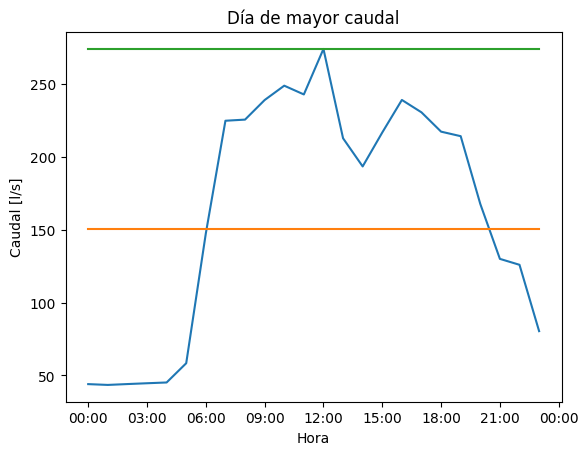

In [6]:
mini = df[df['Time'].dt.year == 2019]

vMean = mini.loc[:, 'Q'].mean()

dfMax = mini.loc[mini['Q'] == mini['Q'].max(),:]
dfMin = mini.loc[mini['Q'] == mini['Q'].min(),:]
vtMax = dfMax['Time'].iloc[0].floor(freq = 'd')
vtMin = dfMin['Time'].iloc[0].floor(freq = 'd')

sub = df[(df['Time'] >= vtMax) & (df['Time'] < vtMax + pd.DateOffset(days = 1))]
vMaxi = sub.loc[:, 'Q'].max()

vecTime = [sub['Time'].iloc[0], sub['Time'].iloc[-1]]

k2 = vMaxi / vMean
print('El valor de K2 es de: ' + str(k2))

plt.plot(sub['Time'], sub['Q'])
plt.plot(vecTime, [vMean, vMean])
plt.plot(vecTime, [vMaxi, vMaxi])
dtFmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(dtFmt)
plt.title('Día de mayor caudal')
plt.xlabel('Hora')
plt.ylabel('Caudal [l/s]')
plt.show()